In [1]:
import pandas as pd

df = pd.read_csv('P9_AML_Accounts.csv')

print(df.head())
print(df.info())
print(df.describe())

  Account_ID  Avg_Transaction_Amount_INR  Transaction_Frequency_Monthly  \
0    ACC2000                       43048                             25   
1    ACC2001                       32417                             15   
2    ACC2002                        8924                              8   
3    ACC2003                        4831                             22   
4    ACC2004                       33140                              0   

   Unique_Counterparties_Monthly  Cash_Deposit_Ratio  \
0                              8                0.32   
1                              1                0.19   
2                              1                0.26   
3                              9                0.27   
4                              8                0.18   

   International_Transfer_Ratio  
0                          0.04  
1                          0.10  
2                          0.12  
3                          0.09  
4                          0.13  
<class '

In [2]:
from sklearn.preprocessing import StandardScaler

# Drop Account_ID if it exists, then keep only numeric features for modeling
features = df.drop(columns=['Account_ID'], errors='ignore')
features = features.select_dtypes(include=['number'])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

In [3]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

In [4]:
print(df.groupby('Cluster').mean(numeric_only=True))

         Avg_Transaction_Amount_INR  Transaction_Frequency_Monthly  \
Cluster                                                              
0                       7598.018868                      12.433962   
1                       7616.000000                      63.250000   
2                      26916.000000                      10.016129   
3                      43899.846154                      11.661538   

         Unique_Counterparties_Monthly  Cash_Deposit_Ratio  \
Cluster                                                      
0                             5.528302            0.229057   
1                            25.350000            0.786500   
2                             5.403226            0.224355   
3                             4.353846            0.232000   

         International_Transfer_Ratio  
Cluster                                
0                            0.074717  
1                            0.554000  
2                            0.086290  
3     

In [5]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.05, random_state=42)

df['Anomaly_Label'] = iso.fit_predict(X_scaled)

# Convert: -1 → anomaly, 1 → normal
df['Is_Anomaly'] = df['Anomaly_Label'].apply(lambda x: 1 if x == -1 else 0)

Missing values by column:
Avg_Transaction_Amount_INR       0
Transaction_Frequency_Monthly    0
Unique_Counterparties_Monthly    0
Cash_Deposit_Ratio               0
International_Transfer_Ratio     0
dtype: int64

Cluster sizes:
Cluster
0    53
1    20
2    62
3    65
Name: count, dtype: int64


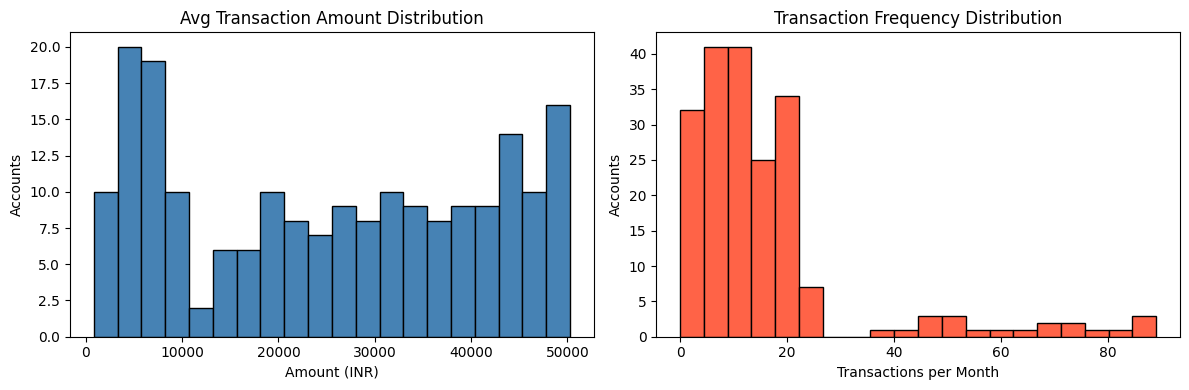

In [6]:
import matplotlib.pyplot as plt

feature_cols = [
    'Avg_Transaction_Amount_INR',
    'Transaction_Frequency_Monthly',
    'Unique_Counterparties_Monthly',
    'Cash_Deposit_Ratio',
    'International_Transfer_Ratio',
]

print('Missing values by column:')
print(df[feature_cols].isnull().sum())

print('\nCluster sizes:')
print(df['Cluster'].value_counts().sort_index())

# Quick EDA plots for feature spread
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['Avg_Transaction_Amount_INR'], bins=20, color='steelblue', edgecolor='black')
axes[0].set_title('Avg Transaction Amount Distribution')
axes[0].set_xlabel('Amount (INR)')
axes[0].set_ylabel('Accounts')

axes[1].hist(df['Transaction_Frequency_Monthly'], bins=20, color='tomato', edgecolor='black')
axes[1].set_title('Transaction Frequency Distribution')
axes[1].set_xlabel('Transactions per Month')
axes[1].set_ylabel('Accounts')
plt.tight_layout()
plt.show()

In [7]:
# --- AML TYPOLOGY DETECTION ---

# Define percentiles to establish thresholds for unusual behavior
q75_freq = df['Transaction_Frequency_Monthly'].quantile(0.75)
q25_amt = df['Avg_Transaction_Amount_INR'].quantile(0.25)
q75_cash = df['Cash_Deposit_Ratio'].quantile(0.75)
q25_counter = df['Unique_Counterparties_Monthly'].quantile(0.25)
q75_counter = df['Unique_Counterparties_Monthly'].quantile(0.75)
q75_intl = df['International_Transfer_Ratio'].quantile(0.75)

# 1. Smurfing Detection: High freq, low amount, high cash
df['Smurfing_Flag'] = (
    (df['Transaction_Frequency_Monthly'] >= q75_freq) & 
    (df['Avg_Transaction_Amount_INR'] <= q25_amt) & 
    (df['Cash_Deposit_Ratio'] >= q75_cash)
).astype(int)

# 2. Round-Tripping Detection (Approx): High frequency but few unique counterparties
df['RoundTripping_Flag'] = (
    (df['Transaction_Frequency_Monthly'] >= q75_freq) & 
    (df['Unique_Counterparties_Monthly'] <= max(2, q25_counter))
).astype(int)

# 3. Layering Detection: High number of counterparties & high international transfers
df['Layering_Flag'] = (
    (df['Unique_Counterparties_Monthly'] >= q75_counter) & 
    (df['International_Transfer_Ratio'] >= q75_intl)
).astype(int)

# Calculate Anomaly Scores + Cluster Risk (used for base risk modeling)
cluster_profile = df.groupby('Cluster')[feature_cols].mean(numeric_only=True).copy()
driver_weights = {'Cash_Deposit_Ratio': 0.35, 'International_Transfer_Ratio': 0.35, 'Transaction_Frequency_Monthly': 0.20, 'Unique_Counterparties_Monthly': 0.10}
weighted_cluster_risk = sum(cluster_profile[col] * wt for col, wt in driver_weights.items())
cluster_risk_norm = (weighted_cluster_risk - weighted_cluster_risk.min()) / (weighted_cluster_risk.max() - weighted_cluster_risk.min() + 1e-9)
df['Cluster_Risk'] = df['Cluster'].map(cluster_risk_norm.to_dict())

raw_anomaly = -iso.decision_function(X_scaled)
df['Anomaly_Score'] = (raw_anomaly - raw_anomaly.min()) / (raw_anomaly.max() - raw_anomaly.min() + 1e-9)

In [8]:
# --- EXPLAINABILITY & COMPOSITE RISK SCORING ---

def generate_reason(row):
    reasons = []
    if row['Smurfing_Flag']:
        reasons.append("High frequency + low amount + high cash deposit ratio \u2192 possible smurfing")
    if row['RoundTripping_Flag']:
        reasons.append("High frequency with few counterparties \u2192 possible round-tripping")
    if row['Layering_Flag']:
        reasons.append("Many counterparties + high international transfers \u2192 possible layering network")
    
    if row['Anomaly_Score'] > 0.8:
        reasons.append("Statistically anomalous compared to dataset")
    
    if not reasons:
        return "Behavior consistent with peer norms"
    return " | ".join(reasons)

df['Reason'] = df.apply(generate_reason, axis=1)

# Calculate Final Risk Score (0-100)
# Weight components: Base anomalis (Isolation Forest), Macro Cluster deviation, and explicit AML typologies
base_risk = (0.5 * df['Anomaly_Score'] + 0.3 * df['Cluster_Risk'] + 0.2 * df['Is_Anomaly'])
pattern_penalty = 0.2 * (df['Smurfing_Flag'] + df['RoundTripping_Flag'] + df['Layering_Flag']).clip(0, 1)

# Combine, scale to 100, and ensure ceiling at 100
df['Risk_Score'] = ((base_risk + pattern_penalty) * 100).clip(0, 100)

# Final Classification (Risk_Level: Low, Medium, High)
def assign_risk_level(score):
    if score >= 75:
        return "High"
    elif score >= 50:
        return "Medium"
    return "Low"

df['Risk_Level'] = df['Risk_Score'].apply(assign_risk_level)

# Filter for top flagged accounts for output
target_cols = ['Account_ID', 'Risk_Score', 'Risk_Level', 'Smurfing_Flag', 'RoundTripping_Flag', 'Layering_Flag', 'Reason']
top_alerts = df.sort_values(by='Risk_Score', ascending=False).head(10)

print("Top 10 High-Risk Accounts Detailed Summary:")
print(top_alerts[target_cols].to_string(index=False))

Top 10 High-Risk Accounts Detailed Summary:
Account_ID  Risk_Score Risk_Level  Smurfing_Flag  RoundTripping_Flag  Layering_Flag                                                                                                                                                                                                   Reason
   ACC2045       100.0       High              0                   0              1                                                                                                                           Many counterparties + high international transfers → possible layering network
   ACC2068       100.0       High              0                   0              1                                                                             Many counterparties + high international transfers → possible layering network | Statistically anomalous compared to dataset
   ACC2069       100.0       High              1                   0              1 High frequency + 


***************************************************
           SUSPICIOUS ACTIVITY REPORT (SAR)
***************************************************
Reporting Entity: GlobalBank Compliance Desk
Account ID: ACC2045
Risk Level: High
Risk Score (0-100): 100.0

--- TRIGGERS ---
Smurfing Detected      : No
Round-Tripping Detected: No
Layering Detected      : Yes

--- ANALYST NARRATIVE (REASON) ---
Many counterparties + high international transfers → possible layering network

--- ACCOUNT METRICS ---
Transaction Frequency (monthly)   : 46
Avg Transaction Amount (INR)      : 9526
Unique Counterparties (monthly)   : 30
Cash Deposit Ratio                : 0.64
International Transfer Ratio      : 0.6

--- RECOMMENDED ACTIONS ---
1) Escalate for enhanced due diligence (EDD) and transaction-level review.
2) Block immediate international transfers if Layering is suspected.
3) Submit final SAR to applicable FIU/regulator within required 30-day timeline.
**********************************************

C:\Users\jaink\AppData\Local\Temp\ipykernel_24860\650301732.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=flags_sum.index, y=flags_sum.values, ax=axes[1], palette='Set2')
C:\Users\jaink\AppData\Local\Temp\ipykernel_24860\650301732.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y='Risk_Score', data=df, ax=axes[2], palette='viridis')


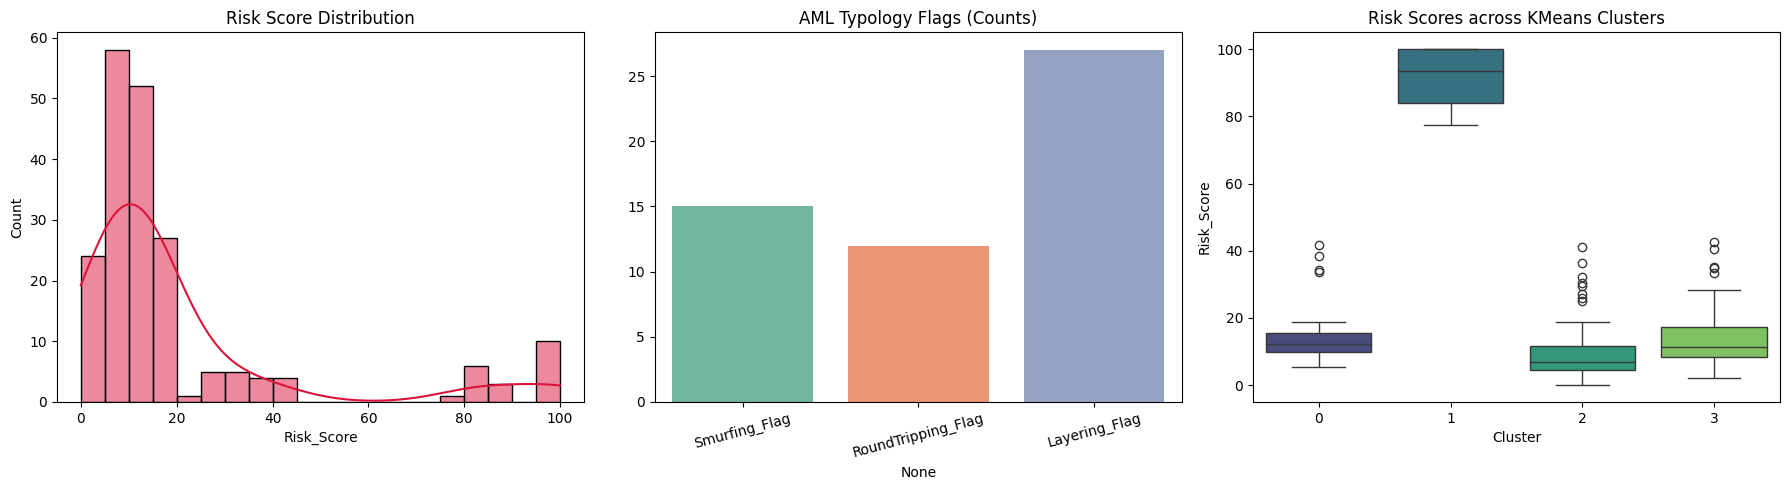

In [9]:
import seaborn as sns

# --- SAR REPORT GENERATION ---

if not top_alerts.empty:
    top_account = top_alerts.iloc[0]
    
    sar_template = f"""
***************************************************
           SUSPICIOUS ACTIVITY REPORT (SAR)
***************************************************
Reporting Entity: GlobalBank Compliance Desk
Account ID: {top_account['Account_ID']}
Risk Level: {top_account['Risk_Level']}
Risk Score (0-100): {top_account['Risk_Score']:.1f}

--- TRIGGERS ---
Smurfing Detected      : {'Yes' if top_account['Smurfing_Flag'] else 'No'}
Round-Tripping Detected: {'Yes' if top_account['RoundTripping_Flag'] else 'No'}
Layering Detected      : {'Yes' if top_account['Layering_Flag'] else 'No'}

--- ANALYST NARRATIVE (REASON) ---
{top_account['Reason']}

--- ACCOUNT METRICS ---
Transaction Frequency (monthly)   : {top_account['Transaction_Frequency_Monthly']}
Avg Transaction Amount (INR)      : {top_account['Avg_Transaction_Amount_INR']}
Unique Counterparties (monthly)   : {top_account['Unique_Counterparties_Monthly']}
Cash Deposit Ratio                : {top_account['Cash_Deposit_Ratio']}
International Transfer Ratio      : {top_account['International_Transfer_Ratio']}

--- RECOMMENDED ACTIONS ---
1) Escalate for enhanced due diligence (EDD) and transaction-level review.
2) Block immediate international transfers if Layering is suspected.
3) Submit final SAR to applicable FIU/regulator within required 30-day timeline.
***************************************************
"""
    print(sar_template)
else:
    print('No flags triggered, SAR report bypassed.')

# --- VISUALIZATIONS ---

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Risk Score Distribution
sns.histplot(df['Risk_Score'], bins=20, kde=True, ax=axes[0], color='crimson')
axes[0].set_title('Risk Score Distribution')

# Flag Counts
flags_sum = df[['Smurfing_Flag', 'RoundTripping_Flag', 'Layering_Flag']].sum()
sns.barplot(x=flags_sum.index, y=flags_sum.values, ax=axes[1], palette='Set2')
axes[1].set_title('AML Typology Flags (Counts)')
axes[1].tick_params(axis='x', rotation=15)

# Cluster vs Risk Score Plot
sns.boxplot(x='Cluster', y='Risk_Score', data=df, ax=axes[2], palette='viridis')
axes[2].set_title('Risk Scores across KMeans Clusters')

plt.tight_layout()
plt.show()